<a href="https://colab.research.google.com/github/nattapongbam/Models-for-Tuberculosis/blob/main/TabTransformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from imblearn.ensemble import EasyEnsembleClassifier
from sklearn.datasets import make_classification
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

In [ ]:
X_train = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/classify วัณโรค /binary/binary_en/X_train_Bi31.csv')#.drop(columns=['Unnamed: 0'])
y_train = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/classify วัณโรค /binary/binary_en/y_train_Bi31.csv')#.drop(columns=['Unnamed: 0'])

X_test = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/classify วัณโรค /binary/binary_en/X_test_Bi30.csv')#.drop(columns=['Unnamed: 0'])
y_test = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/classify วัณโรค /binary/binary_en/y_test_Bi30.csv')#.drop(columns=['Unnamed: 0'])

In [ ]:
X_train.drop(columns='period_treatment', inplace=True)
X_test.drop(columns='period_treatment', inplace=True)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# ==========================================
# Focal Loss: บีบให้โมเดลสนใจเคสที่ทายยาก (Hard Examples)
# ==========================================
class FocalLossPyTorch(nn.Module):
    def __init__(self, alpha=0.4, gamma=1.5):
        super(FocalLossPyTorch, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        # inputs คือ Logits (ยังไม่ผ่าน Sigmoid)
        BCE_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-BCE_loss)
        alpha_t = targets * self.alpha + (1 - targets) * (1 - self.alpha)
        focal_loss = alpha_t * (1 - pt)**self.gamma * BCE_loss
        return torch.mean(focal_loss)

# ===============================================
# TabTransformer: เวอร์ชันเพรียวบางสำหรับข้อมูลการแพทย์
# ===============================================
class TabTransformerBinary(nn.Module):
    def __init__(self, n_binary_features, n_numeric_features, d_token=8, n_heads=4, n_layers=1):
        super(TabTransformerBinary, self).__init__()

        # 1. Categorical Part: สำหรับคอลัมน์ที่เป็น 0/1 (Binary Encoded)
        # เราจะสร้าง Embedding ขนาด [2 x d_token] สำหรับทุกคอลัมน์ binary
        self.embeddings = nn.ModuleList([
            nn.Embedding(2, d_token) for _ in range(n_binary_features)
        ])

        # Transformer Layer: หาความสัมพันธ์ระหว่างฟีเจอร์ที่ถูก Encode มา
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_token, nhead=n_heads, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        # 2. MLP Part: รวมข้อมูลเข้าด้วยกัน
        # ขนาด Input = (จำนวนคอลัมน์ binary * d_token) + จำนวนคอลัมน์ตัวเลข
        input_size_mlp = (n_binary_features * d_token) + n_numeric_features

        self.mlp = nn.Sequential(
            # --- ส่วนขาขึ้น (Up) ---
            nn.Linear(input_size_mlp, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Dropout(0.1),

            # --- ส่วนขาลง (Down) ---
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            # nn.Dropout(0.2), # สามารถใส่เพิ่มตรงนี้ได้ถ้ายัง Overfit
            nn.Linear(32, 1)
        )

    def forward(self, x_num, x_bin):
        # x_bin: [batch, n_binary_features] (ต้องเป็น Long tensor 0 หรือ 1)
        # x_num: [batch, n_numeric_features]

        # ทำ Embedding ทุกคอลัมน์ binary: [batch, n_binary_features, d_token]
        bin_embs = torch.stack([embed(x_bin[:, i]) for i, embed in enumerate(self.embeddings)], dim=1)

        # ผ่าน Transformer เพื่อหา Context ของโรคและประวัติคนไข้
        transformed_bin = self.transformer(bin_embs)

        # Flatten: [batch, n_binary_features * d_token]
        flattened_bin = transformed_cat = transformed_bin.flatten(1)

        # ต่อ (Concat) กับข้อมูลตัวเลข (weight, age, period_treatment)
        combined = torch.cat([flattened_bin, x_num], dim=1)

        # ส่งเข้า MLP เพื่อทำนายผล
        logits = self.mlp(combined)
        return logits

In [ ]:
# รายชื่อคอลัมน์ (อ้างอิงจากภาพ image_aa8903.png)
binary_cols = [col for col in X_train.columns if col not in ['weight', 'age']]
numeric_cols = ['weight', 'age']

# แปลง Binary Features เป็น Long (สำหรับ Embedding)
X_train_bin = torch.tensor(X_train[binary_cols].values).long()
X_test_bin = torch.tensor(X_test[binary_cols].values).long()

# แปลง Numeric Features เป็น Float
X_train_num = torch.tensor(X_train[numeric_cols].values).float()
X_test_num = torch.tensor(X_test[numeric_cols].values).float()

# แปลง Target (y_train, y_test) เป็น Float
# ใช้ y_train ที่คุณได้จากการ split มาใช้ได้เลย ไม่ต้องเรียกจาก df แล้ว
y_train_tensor = torch.tensor(y_train.values).float().view(-1, 1)
y_test_tensor = torch.tensor(y_test.values).float().view(-1, 1)

# สร้างโมเดล
model = TabTransformerBinary(n_binary_features=len(binary_cols),
                             n_numeric_features=len(numeric_cols),
                             d_token=16) # มิติเล็กเพื่อให้เหมาะกับข้อมูล

criterion = FocalLossPyTorch(alpha=0.45, gamma=1.2) # ใช้ Gamma สูงเพื่อบดขยี้ Blind Spots
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [ ]:
import torch
from sklearn.metrics import classification_report, f1_score

# ตั้งค่าจำนวนรอบ (Epochs)
epochs = 60

print("--- เริ่มการเทรน TabTransformer ---")

for epoch in range(epochs):
    # --- โหมดเทรน ---
    model.train()
    optimizer.zero_grad() # ล้างค่า Gradient เดิม

    # Forward Pass: ส่งข้อมูลเข้าโมเดล
    # ต้องส่งทั้งข้อมูลตัวเลข (Numeric) และข้อมูล Binary ตามลำดับที่เขียนใน Forward ของโมเดล
    logits = model(X_train_num, X_train_bin)

    # คำนวณ Loss
    loss = criterion(logits, y_train_tensor)

    # Backward Pass: คำนวณย้อนกลับเพื่อหาทิศทางการปรับน้ำหนัก
    loss.backward()

    # Optimizer Step: ปรับน้ำหนักโมเดลจริง
    optimizer.step()

    # --- ประเมินผลทุกๆ 20 รอบ ---
    if (epoch + 1) % 20 == 0:
        model.eval() # เปลี่ยนเป็นโหมดประเมิน (ปิด Dropout)
        with torch.no_grad(): # ปิดการคำนวณ Gradient เพื่อประหยัด Memory
            test_logits = model(X_test_num, X_test_bin)
            # แปลง Logits เป็นความน่าจะเป็น (0-1) ด้วย Sigmoid
            probs = torch.sigmoid(test_logits)
            # ตัดเกณฑ์ที่ 0.5 เพื่อแยก Class (0 หรือ 1)
            preds = (probs > 0.5).float()

            # คำนวณ Macro F1 เพื่อดูความก้าวหน้า
            current_f1 = f1_score(y_test_tensor.numpy(), preds.numpy(), average='macro')

        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}, Test Macro F1: {current_f1:.4f}")

print("--- เทรนเสร็จสิ้น ---")

--- เริ่มการเทรน TabTransformer ---
Epoch [20/60], Loss: 0.1385, Test Macro F1: 0.6168
Epoch [40/60], Loss: 0.1407, Test Macro F1: 0.5256
Epoch [60/60], Loss: 0.1261, Test Macro F1: 0.6564
--- เทรนเสร็จสิ้น ---


In [ ]:
model.eval()
with torch.no_grad():
    final_logits = model(X_test_num, X_test_bin)
    final_probs = torch.sigmoid(final_logits).numpy()
    final_preds = (final_probs > 0.5).astype(int)

print("\n--- Final Classification Report (TabTransformer) ---")
# เปรียบเทียบ y_test จริง กับค่าที่โมเดลทาย (final_preds)
print(classification_report(y_test, final_preds, target_names=['Death', 'Success'], digits=4))


--- Final Classification Report (TabTransformer) ---
              precision    recall  f1-score   support

       Death     0.5301    0.4292    0.4744       636
     Success     0.8121    0.8664    0.8384      1811

    accuracy                         0.7528      2447
   macro avg     0.6711    0.6478    0.6564      2447
weighted avg     0.7388    0.7528    0.7438      2447



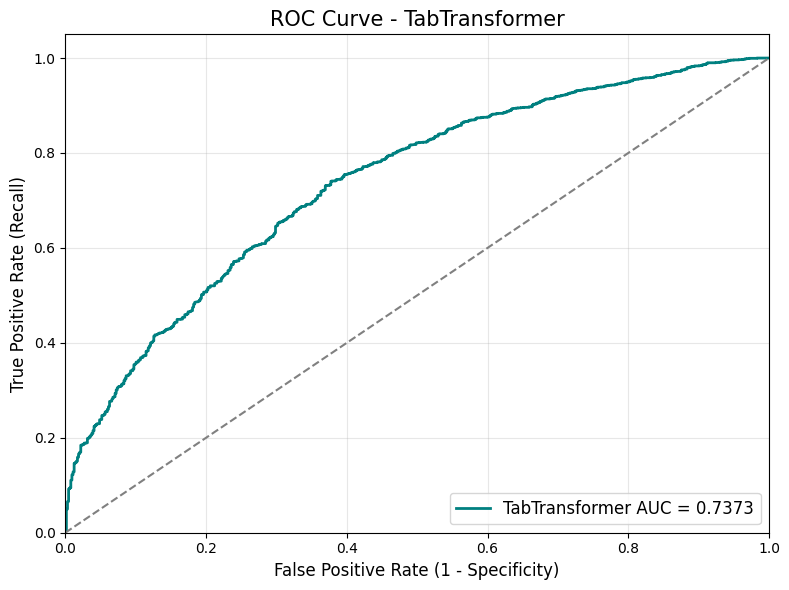

ค่า AUC Score สำหรับโมเดลนี้คือ: 0.7373


In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 1. คำนวณค่า FPR, TPR และ AUC
# final_probs ของคุณอาจจะมี shape เป็น (N, 1) ให้ใช้ .ravel() เพื่อทำเป็น 1D array
fpr, tpr, _ = roc_curve(y_test, final_probs.ravel())
roc_auc = auc(fpr, tpr)

# 2. เริ่มการพล็อตกราฟ
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='teal', lw=2, label=f'TabTransformer AUC = {roc_auc:.4f}')

# พล็อตเส้นประแนวทะแยง (แสดงการสุ่มดวง/Baseline)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

# 3. ตกแต่งกราฟ
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curve - TabTransformer', fontsize=15)
plt.legend(loc="lower right", fontsize=12)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"ค่า AUC Score สำหรับโมเดลนี้คือ: {roc_auc:.4f}")